### This notebook computes "P1. SPI intensity and frequency (Standarized Precipitation Index)" indicator for the 27 basins of IKI Project

**Created:** 1//12/2026 by Sophia Bakar (sbakar@rti.org)

**Project #:** 0219481  

**Last modified:** 1/15/2026 by Sophia

**Status:** Complete and loaded into the sql database for the baseline and first future scenario.

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Peligro
 
**Objective:**   

**Compatibility:** 

**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib 
.  
**Further documentation:**  
 
**Inputs:**   

**Outputs:** 
 
**Assumptions:** The annex does not provide guidance for how to classify the frequency of drought months. We use the quartile-based classification approach which is used in P2 to classify the frequency values. This approach needs QC.
 
**Future work:** 
 
**Notes:** We should be able to use the output from waterALLOC for this, but for now we are calculating SPI by querying the met tables from the modeling grupos databases. 

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import geopandas as gpd
import os
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'sgilson'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID = 101 #Indicator ID (Peligro = 1 + 0X where X is the Peligro Indicator number) 

# get scenarios from database 
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: apply the same values to all scenarios
scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).set_index('COMID').to_crs('WGS84')

In [6]:
# function to query the modeling groups databases for daily precipitation
def get_precipitation(scenarios):
    dfs = []

    for grupo in range(1, 13):
        
        #sqlite_path = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite'
        sqlite_path = f"C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite"

        with sqlite3.connect(sqlite_path) as conn:
            for ScnID, scn_info in scenarios.items():

                query = """
                SELECT
                    comid,
                    avg_precip_cm,
                    measured_date
                FROM catchment_met_observations
                WHERE met_source_id = ?;
                """

                met = pd.read_sql_query(
                    query,
                    conn,
                    params=(scn_info['met_source_id'],)
                )

                if met.empty:
                    continue

                met['measured_date'] = pd.to_datetime(met['measured_date'], format='%Y-%m-%d %H:%M:%S %z UTC', errors='coerce' )

                met = met.dropna(subset=['measured_date'])

                # add scenario ID
                met['ScnID'] = ScnID

                dfs.append(met)

    if not dfs:
        return pd.DataFrame(columns=['ScnID', 'comid', 'measured_date', 'avg_precip_cm'])

    df = pd.concat(dfs, ignore_index=True)

    return df[['ScnID', 'comid', 'measured_date', 'avg_precip_cm']]

In [7]:
# define mapping for scenarios and met source IDs in the modeling groups table 
scenarios = {
    1: {"met_source_id": 2},  # Baseline
    2: {"met_source_id": 5},  # Future
}

In [8]:
# get precipitation from the modeling grupos database 
precip_df = get_precipitation(scenarios)

In [12]:
# set up precipitation dataframe for SPI calculation
# convert precip from cm to mm
precip_df['avg_precip_mm'] = precip_df['avg_precip_cm'] * 10
precip_df['measured_date'] = pd.to_datetime(precip_df['measured_date'],errors='coerce',utc=True)

# convert daily precip to monthly
precip_df['year_month'] = precip_df['measured_date'].dt.to_period('M')  # e.g., 1981-01

monthly_precip = (precip_df.groupby(['ScnID', 'comid', 'year_month'])['avg_precip_mm'].sum().reset_index())

# convert year_month back to datetime for plotting
monthly_precip['month_start'] = monthly_precip['year_month'].dt.to_timestamp()

C:\Users\sbakar\AppData\Local\Temp\ipykernel_98876\356084222.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  precip_df['year_month'] = precip_df['measured_date'].dt.to_period('M')  # e.g., 1981-01


In [13]:
# function to calculate spi for a given monthly time series of precipitation and time scale for SPI (where the time scale is the number of months)

def calculate_spi(precip_series,scale):
    # Aggregate precipitation over the specified scale (rolling sum)
    rolling_precip = precip_series.rolling(window=scale, min_periods=scale).sum()

    #remove NaNs and replace 0s with a very small positive value
    rolling_precip_clean = rolling_precip.dropna() + 1e-6

    # Fit the rolling precipitation to a gamma distribution
    shape, loc, scale = gamma.fit(rolling_precip_clean.dropna(), floc=0)  # Force location to zero
    
    # Calculate the cumulative probability for the observed values
    cdf = gamma.cdf(rolling_precip, shape, loc=loc, scale=scale)
    
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    # Convert cumulative probability to SPI (standard normal distribution)
    spi = norm.ppf(cdf)  # Inverse of the normal CDF
    
    return pd.Series(spi, index=precip_series.index)

#function to calculate 1-month spi for each COMID by scenario
def calculate_spi_for_group(group, scale):
    group = group.sort_values('month_start')
    group['SPI_1'] = calculate_spi(group['avg_precip_mm'], scale)
    return group

In [14]:
spi_1month = (monthly_precip.groupby(['ScnID', 'comid']).apply(calculate_spi_for_group, scale=1).reset_index(drop=True))

C:\Users\sbakar\AppData\Local\Temp\ipykernel_98876\1209409523.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spi_1month = (monthly_precip.groupby(['ScnID', 'comid']).apply(calculate_spi_for_group, scale=1).reset_index(drop=True))


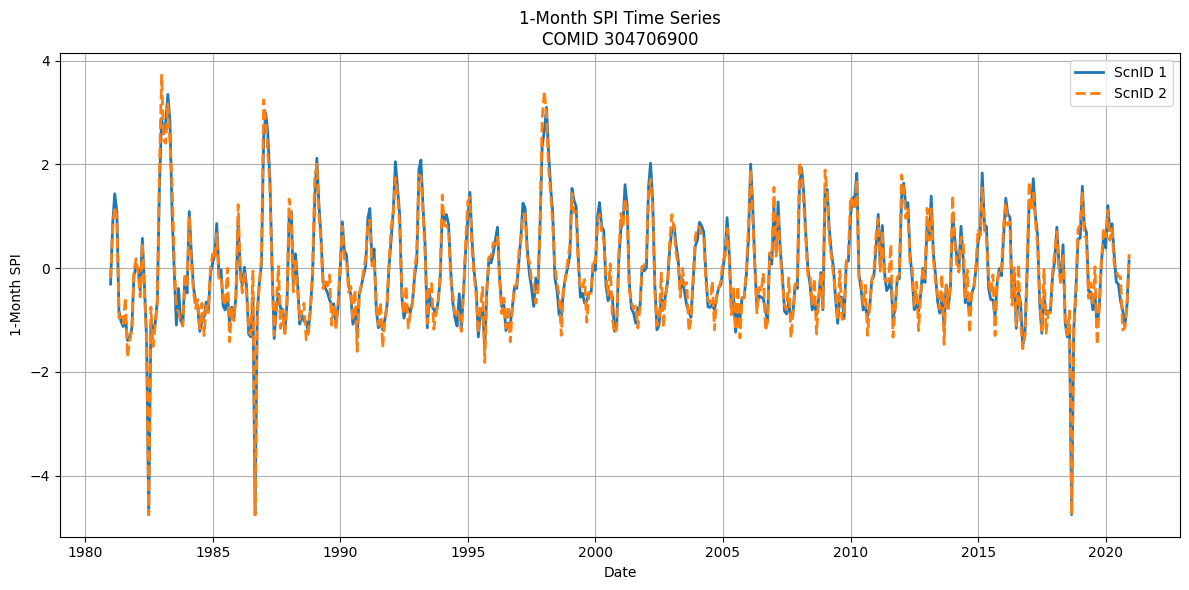

In [15]:
# time series plot for QC

# test COMID
test_comid = '304706900'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_1month[
    (spi_1month['comid'].astype(str) == test_comid) &
    (spi_1month['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_1'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('1-Month SPI')
plt.title(f'1-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# function to classify SPI values into hazard categories
def classify_spi_intensity(spi):
    if spi < -2.0:
        return 4
    elif -2.0 <= spi < -1.5:
        return 3
    elif -1.5 <= spi < -1.0:
        return 2
    elif -1.0 <= spi < 0.0:
        return 1
    else:
        return 1

In [17]:
# apply categorization to SPI values
spi_1month['Intensity'] = spi_1month['SPI_1'].apply(classify_spi_intensity)

In [18]:
# calculate drought frequency (essentially how many months are there where SPI < -1)
spi_1month['Drought_event'] = spi_1month['SPI_1'] < -1.0
freq_df = (spi_1month.groupby(['ScnID', 'comid'])['Drought_event'].sum().reset_index(name='Frequency_count'))

In [26]:
# user quartile-based approach for the hazard classification based on the frequency
Q1 = freq_df['Frequency_count'].quantile(0.25)
Q2 = freq_df['Frequency_count'].quantile(0.50)
Q3 = freq_df['Frequency_count'].quantile(0.75)

In [27]:
# function to classify the frequency values into hazard categories
def map_frequency_to_quartile(freq):
    if freq >= Q3:
        return 4  # Muy Alta
    elif freq >= Q2:
        return 3  # Alta
    elif freq >= Q1:
        return 2  # Media
    else:
        return 1  # Baja

In [28]:
# apply classification
freq_df['Frequency_class'] = freq_df['Frequency_class'] = freq_df['Frequency_count'].apply(map_frequency_to_quartile)


In [29]:
# set up hazard mapping to get final indicator value combining frequency and intensity
hazard_matrix = {
    4: {1: "Medio", 2: "Alto", 3: "Muy alto", 4: "Muy alto"},
    3: {1: "Bajo",  2: "Medio", 3: "Alto",     4: "Alto"},
    2: {1: "Bajo",  2: "Bajo",  3: "Medio",    4: "Medio"},
    1: {1: "Bajo",  2: "Bajo",  3: "Medio",    4: "Medio"},
}

hazard_to_val = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3,
    "Muy alto": 4
}

def compute_hazard(freq_class, intens_class):
    return hazard_matrix[freq_class][intens_class]

In [30]:
# merge frequency back in with intensity
hazard_base = freq_df.merge(spi_1month,on=['ScnID', 'comid'],how='left')

# map the frequency and intensity to the appropriate hazard value and category 
hazard_base['Hazard_category'] = hazard_base.apply(lambda r: compute_hazard(r['Frequency_class'], r['Intensity']),axis=1)
hazard_base['Hazard_value'] = hazard_base['Hazard_category'].map(hazard_to_val)

In [ ]:
## ADD CODE TO PLOT FOR QC

In [32]:
#insert the results into the sqlite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in hazard_base.iterrows():
    rows_to_insert.append((
        int(row['ScnID']),
        IndID,
        int(row['comid']),
        int(row['Hazard_value'])
    ))

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [34]:
# check that the expected min and max values in the indicators table match the calculated values
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats_by_scenario = (
    hazard_base
    .groupby('ScnID')['Hazard_value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Value values by scenario ===")
print(value_stats_by_scenario)

df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 101  Min: 1, Max: 4

=== Value values by scenario ===
   ScnID  min  max    count
0      1    1    4  1754400
1      2    1    4  1465920

Duplicates in rows_to_insert:
         ScnID  IndID      COMID  Value
1            1    101  304273900      1
2            1    101  304273900      1
3            1    101  304273900      1
4            1    101  304273900      2
5            1    101  304273900      1
...        ...    ...        ...    ...
3220315      2    101  320254600      1
3220316      2    101  320254600      1
3220317      2    101  320254600      1
3220318      2    101  320254600      1
3220319      2    101  320254600      1

[3213611 rows x 4 columns]


In [35]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()